# MFAA Chapter 1 Laboratory
**Taxonomy, Cash-Flow Visualization, and the Liquidity-Adjusted Valuation Sandbox** (book §1.9)

This notebook drives the same `engine.ch01` module that powers the webapp and the Excel workbook — identical seeds, identical numbers. Laboratory seed: `20260100`.

In [1]:
import sys, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0, '..')
from engine import ch01
from engine.ch01 import SandboxParams, template
from dataclasses import replace

## 1. Taxonomy (A1)–(A5)
Classify each asset along the five dimensions of Definition 1.2 and read the implied modeling choices.

In [2]:
import pandas as pd
pd.DataFrame([{**{'asset': a['asset']}, **a['profile'], 'note': a['note']} for a in ch01.TAXONOMY])

,asset,A1,A2,A3,A4,A5,note
0,Listed REIT share,False,False,False,False,False,All five fail for the share itself: a liquid w...
1,Direct commercial property,True,True,True,True,True,All five hold; the smoothing model of Section ...
2,Interval fund (private credit),True,True,True,True,False,Hybrid: liquidity exists only at periodic wind...
3,Music-royalty stream,True,True,True,True,False,Cash flows observed on quarterly statements; l...
4,Litigation-finance contract,True,True,True,True,True,Nearest thing to a pure unspanned claim; legal...
5,Gold futures,False,False,False,False,False,Classical asset: the clean negative case.


In [3]:
ch01.IMPLIED_CHOICES

{'A1': 'liquidity states constrain admissible actions (Chs. 5, 13, 14)',
 'A2': 'two filtrations; filtering and de-smoothing (Ch. 6)',
 'A3': 'price bounds, SDF selection, nonlinear operators (Chs. 3, 4, 7)',
 'A4': 'contractual payoff maps: waterfalls, covenants (Chs. 8-12)',
 'A5': 'optimal stopping and control (Ch. 14)'}

## 2. The LDCF sandbox: from number to distribution
Base configuration; the output is a **valuation distribution**, not a number.

In [4]:
p = SandboxParams()   # or template('buyout'), template('private_credit'), ...
out = ch01.sandbox(p)
print(f"mean {out['mean']:.5f}  se {out['se']:.5f}")
out['quantiles']

mean 1.25369  se 0.00841


{'q01': 0.27912603234898725,
 'q05': 0.3940524194387659,
 'q25': 0.6540933020989765,
 'q50': 0.9469358156256389,
 'q75': 1.4204142223294345,
 'q95': 3.04465658961917,
 'q99': 5.9496673711501975}

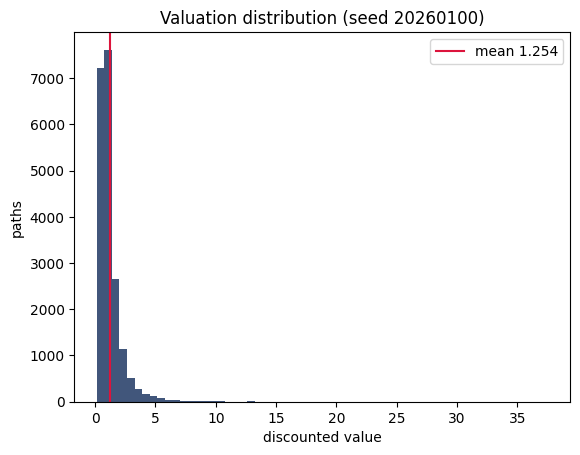

In [5]:
plt.hist(out['values'], bins=60, color='#1F3864', alpha=.85)
plt.axvline(out['mean'], color='crimson', label=f"mean {out['mean']:.3f}")
plt.xlabel('discounted value'); plt.ylabel('paths'); plt.legend(); plt.title('Valuation distribution (seed 20260100)');

## 3. Experiments E1–E4 (assignable before any theory)
**E1 — From number to distribution.** Freeze everything, verify the deterministic DCF, then release risks one at a time.

In [6]:
for fz, label in [(("cash","rate","timing","liquidity"),'deterministic'),
                  (("rate","timing","liquidity"),'cash-flow risk only'),
                  (("timing","liquidity"),'+ rate risk'),
                  (("liquidity",),'+ timing risk'), ((), 'all risks')]:
    s = ch01.summarize(ch01._simulate(p, frozenset(fz))['values'])
    print(f"{label:24s} mean {s['mean']:.4f}  std {s['std']:.4f}  q05 {s['quantiles']['q05']:.4f}  q95 {s['quantiles']['q95']:.4f}")

deterministic            mean 1.3557  std 0.0000  q05 1.3557  q95 1.3557


cash-flow risk only      mean 1.3568  std 0.3265  q05 0.8859  q95 1.9453


+ rate risk              mean 1.3470  std 1.1134  q05 0.3900  q95 3.3315


+ timing risk            mean 1.2598  std 1.1860  q05 0.4099  q95 3.0299


all risks                mean 1.2537  std 1.1898  q05 0.3941  q95 3.0447


**E2 — Covariation and premia.** Vary ρ with λ fixed; the direction of the change in expected value is the covariation argument of §1.7.

In [7]:
for rho in [-0.6,-0.3,0.0,0.3,0.6]:
    s = ch01.summarize(ch01._simulate(replace(p, rho=rho, M=8000))['values'])
    print(f"rho {rho:+.1f}  mean {s['mean']:.4f}")

rho -0.6  mean 1.4218
rho -0.3  mean 1.3590


rho +0.0  mean 1.3003


rho +0.3  mean 1.2429
rho +0.6  mean 1.1863


**E3 — Liquidity as timing risk.** Slow I→Liq and watch the left tail.

In [8]:
for nu in [3.0, 1.5, 0.75, 0.3]:
    s = ch01.summarize(ch01._simulate(replace(p, nu_il=nu, M=8000))['values'])
    print(f"nu_IL {nu:4.2f}  q05 {s['quantiles']['q05']:.4f}  q01 {s['quantiles']['q01']:.4f}  mean {s['mean']:.4f}")

nu_IL 3.00  q05 0.4009  q01 0.2807  mean 1.2673


nu_IL 1.50  q05 0.3882  q01 0.2748  mean 1.2619
nu_IL 0.75  q05 0.3631  q01 0.2457  mean 1.2493


nu_IL 0.30  q05 0.2965  q01 0.1783  mean 1.2153


**E4 — The opening problem, first pass.** Configure the buyout template at a residual six-year horizon: at what fraction of the sandbox mean would you transact? Retain your answer for Chapters 6, 7, 13.

In [9]:
pb = replace(template('buyout'), T=6.0)
sb = ch01.sandbox(pb)
print(f"buyout, 6y residual: mean {sb['mean']:.4f}; q25 {sb['quantiles']['q25']:.4f} = {sb['quantiles']['q25']/sb['mean']:.0%} of mean")

buyout, 6y residual: mean 0.9680; q25 0.5006 = 52% of mean


## 4. Validation checks V1–V4
A simulation that has not passed its anchors is not evidence of anything (LOS 1.7).

In [10]:
val = ch01.validation_checks()
for k, d in val.items():
    if isinstance(d, dict): print(k, 'PASS' if d['pass_'] else 'FAIL')
print('ALL:', val['all_pass'])

V1_deterministic PASS
V2_lambda0 PASS
V3_stability PASS
V4_antithetic PASS
ALL: True


## 5. Risk-source decomposition (Exercise 1.10) and smoothing (Exercises 1.7, 1.11)

In [11]:
rows = ch01.risk_decomposition(template('private_credit'), mode='isolated')
pd.DataFrame([{ 'config': r['config'], 'std': r['std'], **(r['quantiles'] or {})} for r in rows])

,config,std,q01,q05,q25,q50,q75,q95,q99
0,all risks,0.399917,0.071619,0.094570,0.165618,0.270453,0.463367,1.054202,1.998970
1,cash risk only,0.048906,0.318532,0.343642,0.385664,0.416904,0.450475,0.504697,0.544334
2,rate risk only,0.215086,0.147163,0.188149,0.278304,0.373058,0.510600,0.832168,1.180421
3,timing risk only,0.240162,0.095460,0.109918,0.187962,0.323412,0.529051,0.930700,0.930700
4,liquidity risk only,0.001317,0.413260,0.416265,0.419348,0.419587,0.419587,0.419587,0.419587
5,interaction (all-risks std minus sum of isolated),-0.105555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


variance ratio 0.2456 (theory 0.2500)
rho1           0.5899 (theory 0.6000)


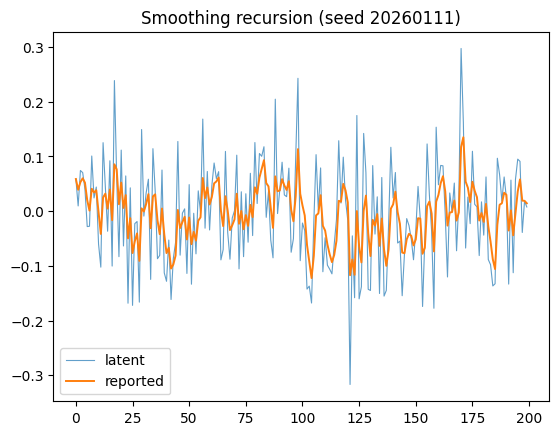

In [12]:
sm = ch01.simulate_smoothing()
print(f"variance ratio {sm['variance_ratio_sample']:.4f} (theory {sm['variance_ratio_theory']:.4f})")
print(f"rho1           {sm['rho1_sample']:.4f} (theory {sm['rho1_theory']:.4f})")
plt.plot(sm['latent'][:200], lw=.8, alpha=.7, label='latent')
plt.plot(sm['reported'][:200], lw=1.4, label='reported')
plt.legend(); plt.title('Smoothing recursion (seed 20260111)');